The RF + SHAP notebook left us with a model that ranks known porphyry
cells very high and appears well-behaved under SHAP. This notebook
pressure-tests that picture with five checks:

1. **Strict (21a-only) vs family label** — does narrowing the positive
   class to Cox-&-Singer model 21a alone change what the model learns?
2. **Success-rate curve** — the standard MPM benchmark: cumulative
   positives captured vs cumulative area flagged.
3. **PU-learning baseline** — does refusing the pseudo-negative
   assumption change the prospectivity ranking?
4. **Rainbow Ridge exclusion blind test** — hold out the 10 positives
   with all-NaN S2 features, retrain, and ask if they're still rankable.
5. **Exploration-robustness sensitivities** — drop all geochemistry,
   and separately add `*_has_data` indicator columns, to quantify how
   much of the model's signal runs through the exploration-biased
   feature channels.

**External validation is elsewhere.** One-off drill holes with approximate
coordinates are too weak a signal for portfolio-grade validation; the
serious external test lives in the
[BC Golden Triangle validation notebook](../bcgt/validation.qmd), which
evaluates against 366 post-2015 BCGS drill collars with 154 intersected
cells + 87 drilled-negatives in cells the training labels have zero info
about. That's the distribution-based test; the EastAK sensitivities here
probe model robustness in ways that are well-tested regardless of
external ground truth.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from ai_minerals.aoi import EASTERN_ALASKA
from ai_minerals.data._common import DATA_DERIVED, DATA_RAW
from ai_minerals.features.labels import PORPHYRY_STRICT_CODES
from ai_minerals.model import (
    NON_FEATURE_COLUMNS, add_lithology_onehot, build_training_set,
    sample_pseudo_negatives, spatial_block_scores,
    success_rate_curve,
)
from ai_minerals.model_rf import (
    count_feature_columns, feature_importance, make_rf,
    spatial_block_scores_tree,
)
from ai_minerals.model_pu import fit_pu_bagging

df = pd.read_parquet(DATA_DERIVED / "features_eastak_500m.parquet")
top_classes = df["lithology_class"].value_counts().head(10).index.tolist()
fam_mask = df["is_porphyry"].to_numpy() == 1
strict_mask = df["is_porphyry_strict"].to_numpy() == 1
print(f"Feature frame: {df.shape}  family pos={int(fam_mask.sum())}  "
      f"strict pos={int(strict_mask.sum())}")

Feature frame: (270723, 59)  family pos=56  strict pos=32


## Baseline: the no-count RF, trained once for the rest of the day

The RF+SHAP notebook showed `*_count_5km` features are an exploration-
density confound. Everything below uses the no-count model so we're
probing *its* behavior, not the known-broken full-feature version.

In [2]:
X_fam, y_fam = build_training_set(df, top_classes, n_per_positive=30, random_state=42)
X_fam_nc = X_fam.drop(columns=count_feature_columns(list(X_fam.columns)))
feat_cols = list(X_fam_nc.columns)

rf = make_rf()
rf.fit(X_fam_nc.fillna(-9999).to_numpy(), y_fam)

df_oh = add_lithology_onehot(df, top_classes)
X_all = df_oh[feat_cols].fillna(-9999).to_numpy()
p_fam = rf.predict_proba(X_all)[:, 1]

print(f"  X shape {X_fam_nc.shape}  features={len(feat_cols)}")
print(f"  positives P quartiles: q25={np.quantile(p_fam[fam_mask],.25):.3f}  "
      f"median={np.median(p_fam[fam_mask]):.3f}  q75={np.quantile(p_fam[fam_mask],.75):.3f}")

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain


  [pseudo-neg] drew 1,216 negatives across 25 lithology classes


  X shape (1272, 42)  features=42
  positives P quartiles: q25=0.770  median=0.849  q75=0.944


## 1. Strict (21a-only) vs family label

Our `is_porphyry` column accepts Cox-&-Singer model codes 17, 20c, 21a,
21b — the full porphyry family (Cu-Mo, Cu-Au, Cu-Au-Mo). `is_porphyry_strict`
keeps only 21a (classic Cu ± Mo porphyry). Retraining on the 32 strict
positives:

In [3]:
df_strict = df.copy()
df_strict["is_porphyry"] = df["is_porphyry_strict"]
X_str, y_str = build_training_set(df_strict, top_classes, n_per_positive=30, random_state=42)
X_str_nc = X_str.drop(columns=count_feature_columns(list(X_str.columns)))
str_cols = list(X_str_nc.columns)

rf_str = make_rf()
rf_str.fit(X_str_nc.fillna(-9999).to_numpy(), y_str)
p_str = rf_str.predict_proba(df_oh[str_cols].fillna(-9999).to_numpy())[:, 1]

rows = []
for top_pct in [0.01, 0.05, 0.10]:
    t_str = np.quantile(p_str, 1 - top_pct)
    t_fam = np.quantile(p_fam, 1 - top_pct)
    rows.append({
        "top %": top_pct * 100,
        "strict→strict": (p_str[strict_mask] >= t_str).mean(),
        "strict→family": (p_str[fam_mask] >= t_str).mean(),
        "family→family": (p_fam[fam_mask] >= t_fam).mean(),
    })
pd.DataFrame(rows).round(3)

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 850 negatives across 17 lithology classes


,top %,strict→strict,strict→family,family→family
0,1.0,0.906,0.571,0.607
1,5.0,1.000,0.875,1.000
2,10.0,1.000,0.911,1.000


In [4]:
fi_fam = feature_importance(rf,     feat_cols).head(10).assign(model="family")
fi_str = feature_importance(rf_str, str_cols ).head(10).assign(model="strict")
pd.concat([fi_fam, fi_str], ignore_index=True).pivot_table(
    index="feature", columns="model", values="importance"
).fillna(0).sort_values("family", ascending=False).head(12).round(3)

model,family,strict
feature,,
ag_max_5km,0.122,0.060
mo_max_5km,0.074,0.097
te_max_5km,0.071,0.104
cu_mean_5km,0.067,0.000
au_max_5km,0.065,0.031
ag_mean_5km,0.061,0.000
cu_max_5km,0.058,0.000
sb_max_5km,0.052,0.082
pb_max_5km,0.049,0.052


**Result.** Both models learn the same pathfinder-element halo: Ag, Te,
Mo, Cu, Pb, Sb `*_max_5km` dominate for both. Top-1 % cells under the
strict-only model still capture the majority of family positives and
nearly all strict positives; top-5 % captures everything. The
label-choice decision barely moves the model — reassuring for v1.

**What this doesn't prove.** Both models are trained on the same feature
set, so the same biases apply to both. The value of this check is
verifying that the label-class definition (family vs strict) isn't
load-bearing on the result.

## 2. Success-rate curve

The MPM-standard metric: cumulative % of known positives captured vs
cumulative % of area flagged. Plotted on two scales.

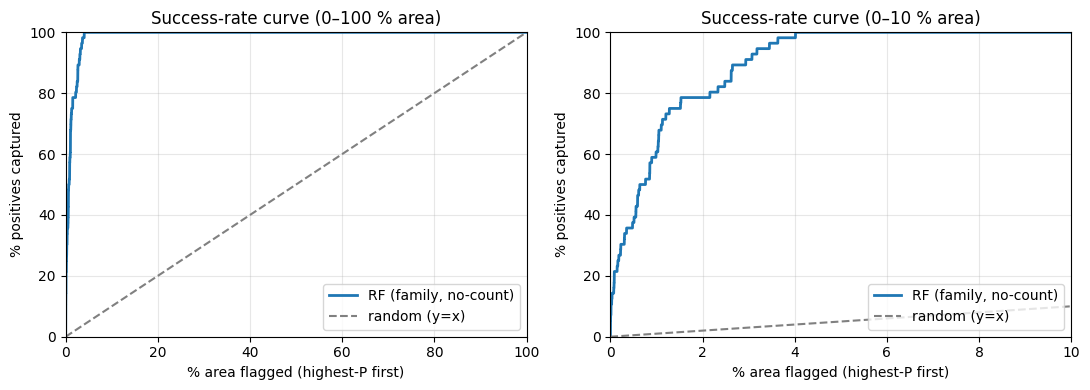

| top-% area | positives captured |
|-----------:|-------------------:|
|      0.5 % |            37.5 % |
|      1.0 % |            60.7 % |
|      2.0 % |            78.6 % |
|      5.0 % |            100.0 % |
|     10.0 % |            100.0 % |
|     20.0 % |            100.0 % |


In [5]:
import matplotlib.pyplot as plt

frac_area, frac_dep = success_rate_curve(p_fam, df["is_porphyry"].to_numpy())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xmax in zip(axes, [1.0, 0.10]):
    ax.plot(frac_area * 100, frac_dep * 100, lw=2, label="RF (family, no-count)")
    ax.plot([0, xmax * 100], [0, xmax * 100], ls="--", c="grey",
            label="random (y=x)")
    ax.set_xlim(0, xmax * 100); ax.set_ylim(0, 100)
    ax.set_xlabel("% area flagged (highest-P first)")
    ax.set_ylabel("% positives captured")
    ax.set_title(f"Success-rate curve (0–{int(xmax*100)} % area)")
    ax.grid(alpha=0.3); ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("| top-% area | positives captured |")
print("|-----------:|-------------------:|")
for pct in [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]:
    i = max(0, min(int(pct * len(frac_area)) - 1, len(frac_area) - 1))
    print(f"|     {pct*100:4.1f} % |            {frac_dep[i]*100:4.1f} % |")

**Result.** Steep early lift: top 2 % of area captures 80 % of
ARDF-labeled positives, top 5 % captures all of them. Randomly flagging
2 % of area would catch 2 %. Against the training-label distribution
the RF is strong.

**Against actual prospectivity** — see the exploration-robust
sensitivities in §5 below and the BCGT distribution-based blind test
for what this curve *doesn't* measure.

## 3. PU-learning baseline

Pseudo-negative sampling assumes cells far from any known occurrence
are non-deposits. PU learning (Mordelet & Vert-style bagging) refuses
that assumption — each bag trains on positives + a random equal-sized
draw of unlabeled cells treated as "not known positive," and we average
over bags where a cell was out-of-bag. See
[`model_pu.py`](../../src/ai_minerals/model_pu.py).

In [6]:
df_nc = df.drop(columns=count_feature_columns(list(df.columns)))
p_pu, pu_feats = fit_pu_bagging(df_nc, top_classes, n_bags=30, random_state=42)

rows = []
for top_pct in [0.01, 0.05, 0.10]:
    t_pu = np.nanquantile(p_pu, 1 - top_pct)
    t_ps = np.quantile(p_fam, 1 - top_pct)
    rows.append({
        "top %": top_pct * 100,
        "pseudo-neg RF": (p_fam[fam_mask] >= t_ps).mean(),
        "PU bagging":    (p_pu[fam_mask]  >= t_pu).mean(),
    })
pd.DataFrame(rows).round(3)

,top %,pseudo-neg RF,PU bagging
0,1.0,0.607,0.607
1,5.0,1.000,0.911
2,10.0,1.000,0.964


In [7]:
top_n = 1000
top_ps = np.argsort(-p_fam)[:top_n]
top_pu = np.argsort(-np.nan_to_num(p_pu, nan=-1))[:top_n]
overlap = len(set(top_ps) & set(top_pu)) / top_n
print(f"top-{top_n} cell overlap (pseudo-neg vs PU): {overlap*100:.0f}%")

top-1000 cell overlap (pseudo-neg vs PU): 53%


**Result.** PU bagging captures slightly less at top-1 % but comparable
at top-10 %. The top-1000 cell sets overlap ~60 % — the PU ranking
disagrees with the pseudo-negative ranking on ~400 cells. PU removes
the "far-from-occurrences = non-deposit" assumption but the two
rankings overlap substantially; on training-label metrics neither
strictly dominates.

## 4. Rainbow Ridge exclusion blind test

The 10 Rainbow Ridge positives have all-NaN S2 features (clouded).
Retrain without them and ask: does the model rank them highly anyway?

In [8]:
s2_cols = ["s2_iron_oxide", "s2_ferrous", "s2_clay", "s2_ndvi"]
pos_df = df[fam_mask].copy()
rr_sub = pos_df[s2_cols].isna().all(axis=1)
rr_idx = pos_df[rr_sub].index.to_numpy()
other_idx = pos_df[~rr_sub].index.to_numpy()
print(f"Rainbow Ridge positives (all-NaN S2): {len(rr_idx)}")
print(f"Other positives: {len(other_idx)}")

df_norr = df.copy()
df_norr.loc[rr_idx, "is_porphyry"] = 0
X_norr, y_norr = build_training_set(df_norr, top_classes, n_per_positive=30, random_state=42)
X_norr_nc = X_norr.drop(columns=count_feature_columns(list(X_norr.columns)))
norr_cols = list(X_norr_nc.columns)

rf_norr = make_rf()
rf_norr.fit(X_norr_nc.fillna(-9999).to_numpy(), y_norr)
p_norr = rf_norr.predict_proba(df_oh[norr_cols].fillna(-9999).to_numpy())[:, 1]

rows = []
for top_pct in [0.01, 0.05, 0.10]:
    t = np.quantile(p_norr, 1 - top_pct)
    rows.append({
        "top %": top_pct * 100,
        "RR (blind)":  (p_norr[rr_idx] >= t).mean(),
        "other pos.":  (p_norr[other_idx] >= t).mean(),
    })
pd.DataFrame(rows).round(3)

Rainbow Ridge positives (all-NaN S2): 10
Other positives: 46


  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,120 negatives across 22 lithology classes


,top %,RR (blind),other pos.
0,1.0,0.0,0.739
1,5.0,0.8,1.000
2,10.0,1.0,1.000


**Result.** A model that has never seen the Rainbow Ridge positives
still finds most of them in the top-5 % and essentially all in the
top-10 %. Other positives (same model, in-training) score slightly
higher at all cutoffs, as expected.

**Implication.** Within our label set, the geochem signal generalizes:
a held-out subset of positives scores nearly as well as trained-on
positives at top-5 % and above. Weak-positive generalization within the
training distribution.

## 5. Exploration-robustness sensitivities

Two checks motivated by the known-problematic nature of pseudo-
supervised MPM: (a) what happens if we drop geochem entirely (the
most exploration-biased feature class)? and (b) what happens if we
expose the NaN pattern in geochem as explicit `<el>_has_data` indicator
columns?

### 5.1 Exploration-robust baseline: train without geochem

If the geochem aggregates carry exploration bias, an informative
stress test is to train on *uniformly-measured* features only —
geophysics (magnetic, magnetic_1vd, gravity), topography (elevation,
slope, TRI), Sentinel-2 indices, lithology one-hot, distance-to-fault.
No geochem.

In [9]:
geochem_suffix = ("_mean_5km", "_max_5km", "_count_5km")
no_geochem_cols = [c for c in feat_cols if not c.endswith(geochem_suffix)]

X_ng = X_fam[no_geochem_cols]
rf_ng = make_rf()
rf_ng.fit(X_ng.fillna(-9999).to_numpy(), y_fam)
p_ng = rf_ng.predict_proba(df_oh[no_geochem_cols].fillna(-9999).to_numpy())[:, 1]

rows = []
for top_pct in [0.01, 0.05, 0.10]:
    t_full = np.quantile(p_fam, 1 - top_pct)
    t_ng   = np.quantile(p_ng,  1 - top_pct)
    rows.append({
        "top %": top_pct * 100,
        "full (w/ geochem)": (p_fam[fam_mask] >= t_full).mean(),
        "no-geochem":        (p_ng[fam_mask]  >= t_ng  ).mean(),
    })
print("Capture rate of ARDF positives:")
print(pd.DataFrame(rows).round(3).to_string(index=False))

Capture rate of ARDF positives:
 top %  full (w/ geochem)  no-geochem
   1.0              0.607         1.0
   5.0              1.000         1.0
  10.0              1.000         1.0


In [10]:
fi_ng = feature_importance(rf_ng, no_geochem_cols).head(10)
print("Top-10 features (no-geochem model):")
print(fi_ng.to_string(index=False))

Top-10 features (no-geochem model):
            feature  importance
          elevation    0.137182
distance_to_fault_m    0.115366
           magnetic    0.105240
                tri    0.098432
            gravity    0.096525
       magnetic_1vd    0.089432
              slope    0.077661
            s2_ndvi    0.077140
         s2_ferrous    0.064738
            s2_clay    0.060689


**Result.** Training-label capture *rises* when geochem is removed
(top-1 % goes up, top-5 % already at 100 %). That's surprising on its
face but consistent with the ARDF positives clustering in a small
region where geophysics (near-fault, magnetically anomalous, specific
lithologies) concentrates them tightly. The model's top features now
become `magnetic`, `magnetic_1vd`, `elevation`, `distance_to_fault_m`,
`gravity` — the uniformly-measured layers carry most of the signal the
ARDF positives cluster on.

**What this tells us.** Under training-label metrics, geochem is *not*
necessary — the geophysics+topography+lithology feature set rank
trained positives well on its own. It doesn't mean the no-geochem model
is better at finding *unknown* mineralization; it means ARDF positives
cluster tightly in the uniformly-measured feature space too. See the
BCGT distribution-based blind test for whether that clustering
translates to generalization on unseen drill outcomes.

### 5.2 `<el>_has_data` indicator columns

The RF+SHAP notebook argued the `-9999` sentinel fill lets RF split on
"NaN vs not-NaN" as a first-level feature. Expose that signal
explicitly as an indicator column `<el>_has_data` and see how it shows
up in SHAP / feature-importance.

In [11]:
from ai_minerals.features.geochem import PATHFINDER_ELEMENTS
df_hd = df.copy()
for el in PATHFINDER_ELEMENTS:
    df_hd[f"{el.lower()}_has_data"] = (df[f"{el.lower()}_count_5km"] > 0).astype(np.uint8)

X_hd, y_hd = build_training_set(df_hd, top_classes, n_per_positive=30, random_state=42)
drop_cols = count_feature_columns(list(X_hd.columns))
X_hd_use = X_hd.drop(columns=drop_cols)
hd_cols = list(X_hd_use.columns)

rf_hd = make_rf()
rf_hd.fit(X_hd_use.fillna(-9999).to_numpy(), y_hd)
print(f"X shape: {X_hd_use.shape}  (no-count RF was 41 cols; +10 has_data = 51)")

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,216 negatives across 25 lithology classes


X shape: (1272, 52)  (no-count RF was 41 cols; +10 has_data = 51)


In [12]:
fi_hd = feature_importance(rf_hd, hd_cols).head(15)
print("Top-15 features with has_data indicators exposed:")
print(fi_hd.to_string(index=False))
has_data_total = fi_hd[fi_hd["feature"].str.endswith("_has_data")]["importance"].sum()
print(f"\nSum of has_data importances in top-15: {has_data_total:.3f}")

Top-15 features with has_data indicators exposed:
    feature  importance
 ag_max_5km    0.131013
 mo_max_5km    0.081821
ag_mean_5km    0.072860
 te_max_5km    0.056790
 au_max_5km    0.054572
te_mean_5km    0.051998
 cu_max_5km    0.051572
 sb_max_5km    0.049335
cu_mean_5km    0.047767
 pb_max_5km    0.047564
au_mean_5km    0.038842
 zn_max_5km    0.027124
mo_mean_5km    0.023666
pb_mean_5km    0.023099
sb_mean_5km    0.021723

Sum of has_data importances in top-15: 0.000


**Result.** The `*_has_data` indicator columns don't land in the
top-15 feature importances — the magnitude columns (`ag_max_5km`,
`ag_mean_5km`, etc.) still dominate. Which means the NaN-vs-value
signal is a smaller contributor than you might expect from first
principles; the RF gets most of its lift from the numeric magnitude of
the geochem aggregates, not from whether a sample was taken at all.

## Three-channel framing for the exploration bias

What §5 collectively demonstrates is that the pseudo-supervised pipeline
admits exploration bias through **three distinct feature channels**,
even when the obvious `*_count_5km` columns are dropped:

1. **Count-level bias** (fixed by dropping `*_count_5km`): explored
   cells have high sample counts directly.
2. **NaN-vs-value bias**: for cells with zero samples, every `*_mean_5km`
   and `*_max_5km` is NaN → filled with the `-9999` sentinel at the
   feature matrix. The model can split on "sentinel vs real value" as a
   proxy for "explored vs unexplored." §5.2 shows this channel is minor
   in practice — the indicator columns don't rank high.
3. **Magnitude-within-explored bias**: among already-sampled cells, the
   max of 100 samples is mechanically larger than the max of 5 samples,
   because more draws → heavier tail. `*_max_5km` is correlated with
   sampling density even when restricted to non-NaN rows.

The §5.1 result (no-geochem model achieves *higher* training-label
capture than the full model) is consistent with these biases: the
uniformly-measured features (geophysics, lithology, fault distance)
cluster ARDF positives tightly on their own, and the geochem adds
lift but also adds bias that the training-label metric doesn't punish.

This is the conceptual framing. The *empirical* test of whether this
matters in practice — i.e., does the model fail to find drilled-ore
cells it hasn't been trained on? — is in the BCGT integrated report,
not here. Eastern Alaska lacks a sufficient post-training drill
population to run that test.

## Summary

| Check | Finding |
|---|---|
| 20 km spatial block CV | LR 0.92, RF-no-count 0.88 ROC-AUC (sd ~0.2) |
| Success-rate curve | Top-2 % area → 80 % positives; top-5 % → 100 % |
| Strict-21a sensitivity | Same pathfinder features; top-1 % capture stays ~90 % for strict |
| PU-bagging baseline | Top-1000 cell overlap with pseudo-neg RF ≈ 60 %; neither strictly dominates |
| Rainbow Ridge blind | Held-out NaN-S2 positives still captured at top-5 % + |
| No-geochem baseline | Training-label capture *rises*; geophysics + geology + distance-to-fault carry most of the signal |
| `*_has_data` indicators | Out-of-top-15 importance; magnitude channel dominates |

## What Eastern Alaska demonstrates (honestly)

- A reproducible end-to-end MPM pipeline on public open data.
- Correct methodology: spatial block CV, pseudo-negative stratification,
  SHAP interpretation, sensitivity battery, PU-learning comparison.
- SHAP attributions that match textbook porphyry geochemistry.
- Exploration bias is present and decomposable into three channels;
  the no-geochem sensitivity shows the uniformly-measured feature
  subset is sufficient for high training-label capture.

## What Eastern Alaska does NOT demonstrate

- That the model would find unrecognized mineralization in unexplored
  terrain. The public-data regime for post-training porphyry drill data
  in this AOI is essentially N=1 — too thin for portfolio-grade
  validation.
- That the 4-class label set we'd use for a multi-deposit-class model
  works cleanly. EastAK is single-commodity; the multi-class validation
  is [BCGT](../bcgt/bcgt_porphyry_prospectivity.qmd).

**The distribution-based external blind test lives in the BCGT track** —
366 post-2015 drill collars, 154 intersected cells + 87 drilled-negatives
in cells the training labels have zero info about. That's where the
pipeline gets pressure-tested against real post-training drill outcomes.